In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [6]:
df = pd.read_csv("mall_dataset.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
X = df.iloc[:, [3,4]].values


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


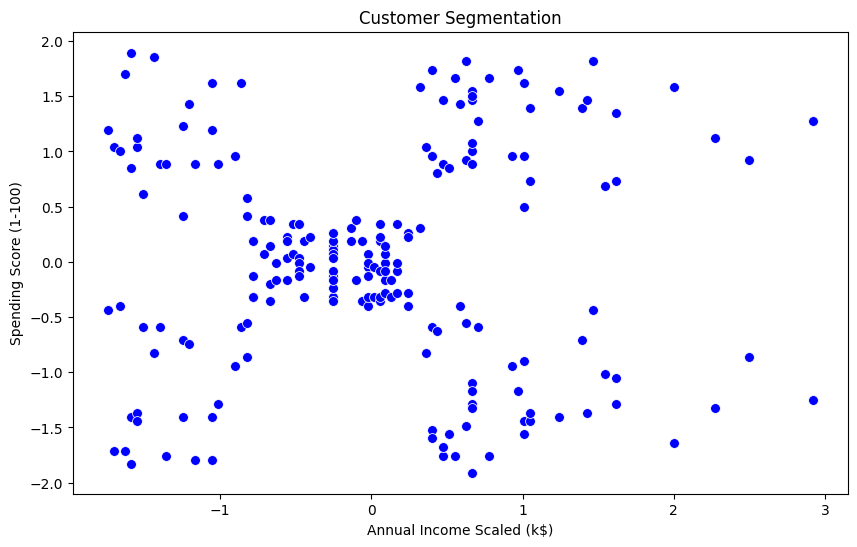

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = X_scaled[:, 0], y  = X_scaled[:, 1],c = 'blue', s = 50)
plt.xlabel('Annual Income Scaled (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.show()

In [10]:
model = KMeans(n_clusters=5, random_state=42)
model.fit(X_scaled)

df['Cluster'] = model.fit_predict(X_scaled)
df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [11]:
# replacing the cluster labels with the original scale values for better visualization
df.replace({'Cluster': {0: 'Low Income, Low Spending',
                        1: 'High Income, High Spending',
                        2: 'High Income, Low Spending',
                        3: 'Low Income, High Spending',
                        4: 'Average Income, Average Spending'}}, inplace=True)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,"Average Income, Average Spending"
1,2,Male,21,15,81,"High Income, Low Spending"
2,3,Female,20,16,6,"Average Income, Average Spending"
3,4,Female,23,16,77,"High Income, Low Spending"
4,5,Female,31,17,40,"Average Income, Average Spending"
...,...,...,...,...,...,...
195,196,Female,35,120,79,"High Income, High Spending"
196,197,Female,45,126,28,"Low Income, High Spending"
197,198,Male,32,126,74,"High Income, High Spending"
198,199,Male,32,137,18,"Low Income, High Spending"


Cluster Centers: [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


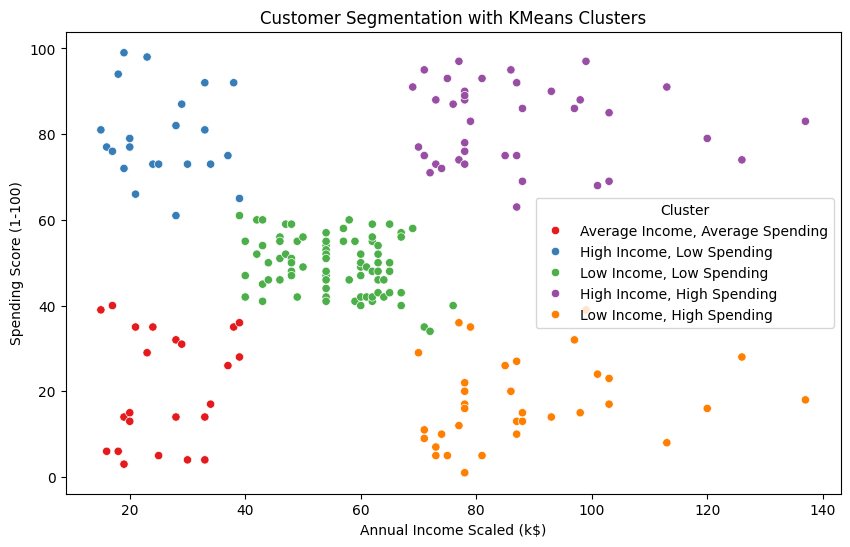

In [12]:

# Cluster centers in the original scale
print(f"Cluster Centers: {model.cluster_centers_}")
# Kmeans grouping visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x = X[:, 0], y  = X[:, 1], hue = df['Cluster'], palette = 'Set1')
plt.xlabel('Annual Income Scaled (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation with KMeans Clusters')
plt.legend(title='Cluster')
plt.show()

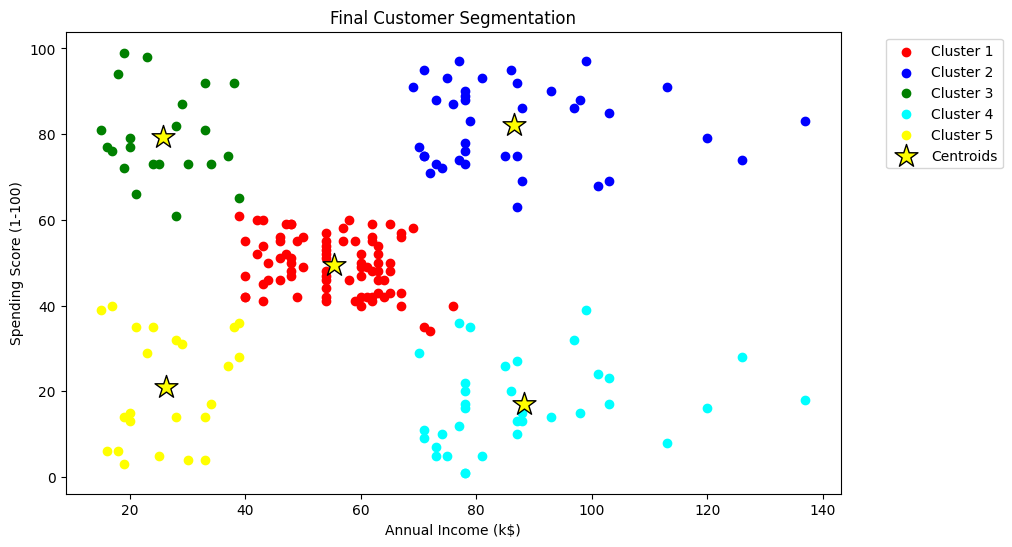

In [23]:
"""kmeans.cluster_centers_
plt.figure(figsize = (10,6))
colors = ['red','blue', 'green', 'cyan', 'yellow']
for i in range(5):
    plt.scatter(X[df['Cluster']==i,0], X[df['Cluster']==i,1], c =colors[i], label='Cluster'+str(i+1))
    plt.legend()

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1], s= 300, c ='yellow', marker = "*", label ='Centroids', edgecolors='black')

plt.title("final")
plt.xlabel("Annual income(k$)")
plt.ylabel('Spending score (1-100)')
plt.legend()
plt.show()"""
plt.figure(figsize = (10,6))

# Assign colors for the clusters
colors = ['red','blue', 'green', 'cyan', 'yellow']

# Use model.labels_ which still contains the integer cluster assignments
for i in range(5):
    plt.scatter(X[model.labels_ == i, 0], X[model.labels_ == i, 1], c=colors[i], label='Cluster '+str(i+1))

# Unscale the cluster centers back to their original values
centroids = scaler.inverse_transform(model.cluster_centers_)

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', marker="*", label='Centroids', edgecolors='black')

plt.title("Final Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
# Call legend once at the end (removed out of the loop)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()
